In [72]:
library(ggplot2)
library(readr)
library(corrplot)
library(FactoMineR)

In [73]:
europe <- read.table(
  "C:/Users/Julien ANTOGNELLI/Documents/ESGI/Maths/MathsForR/data/Donnees Europe.txt",
  header = TRUE,   # 1ère ligne = noms des colonnes
  row.names = 1    # 1ère colonne = noms des lignes (at, be, cy...)
)

# Première ACP

# Introduction au jeu de données

In [74]:
head(europe)

,benev,chom,depedu,depsoc,devel,pib,pvap,pvav,trvpv
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
at,60,4.7,5.45,29.1,0.944,128.8,12,24,6
be,37,8.1,5.99,29.3,0.945,112.3,15,28,3
cy,23,4.6,6.71,17.8,0.903,93.2,16,22,6
cz,33,7.7,4.42,19.6,0.885,79.4,10,21,3
de,52,9.1,4.60,29.5,0.932,113.6,13,24,4
dk,49,4.9,8.47,30.7,0.943,126.7,12,31,4


## Graphes de couples de variables

### Couple `chom`et `depsoc`

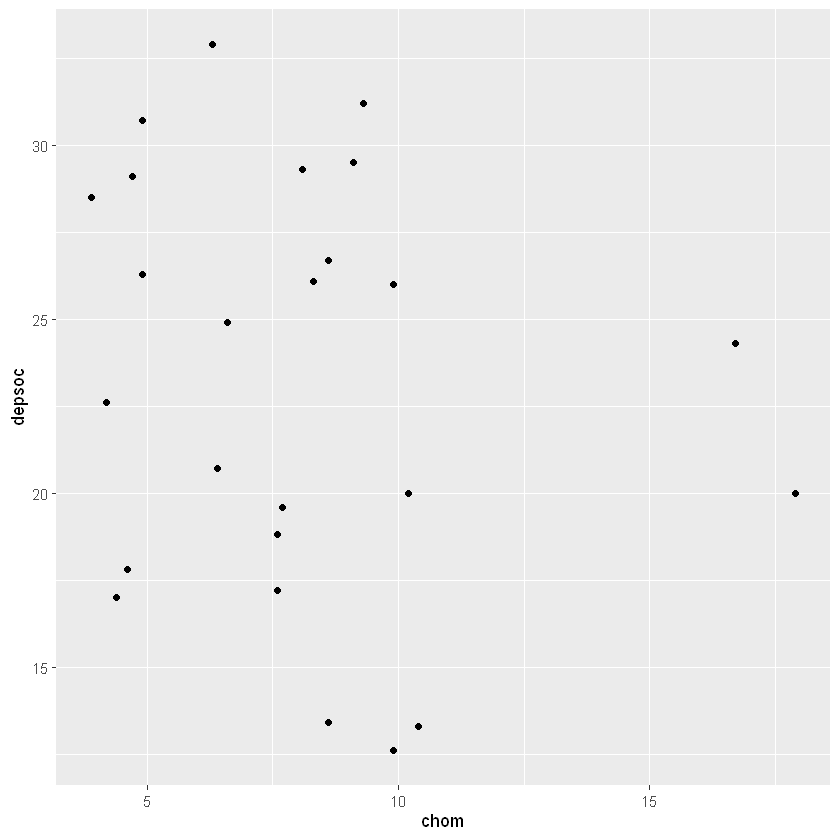

In [75]:
ggplot(europe, aes(x = chom, y = depsoc)) +
  geom_point() +
  labs(x = "chom",
       y = "depsoc")


### Couple `PIB`et `devel`

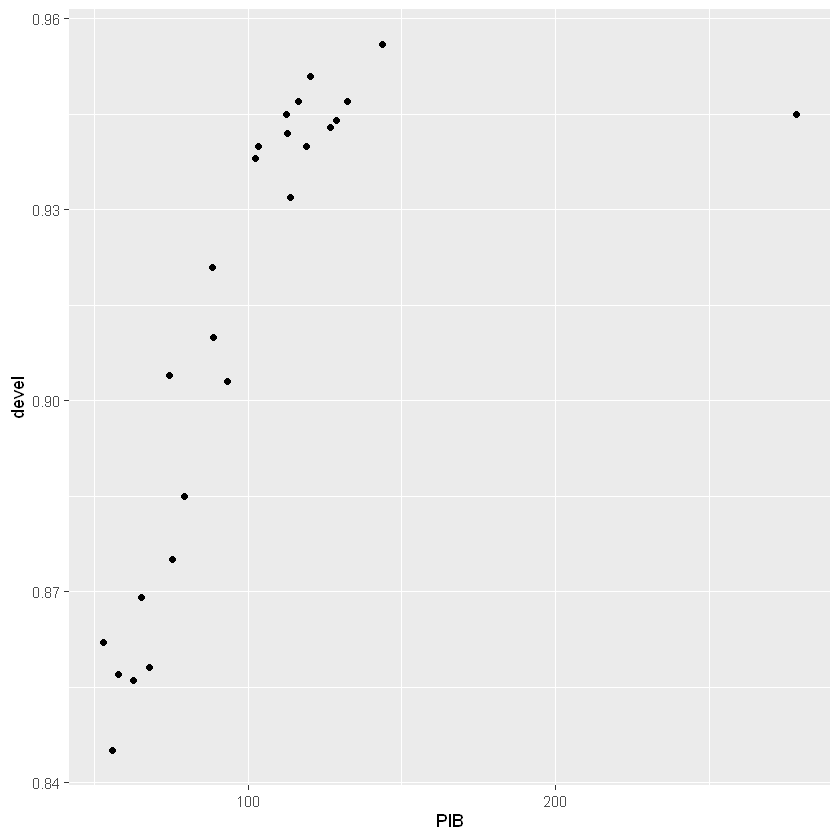

In [76]:
ggplot(europe, aes(x = pib, y = devel)) +
  geom_point() +
  labs(x = "PIB",
       y = "devel")

### Couple `benev`et `pvapr`

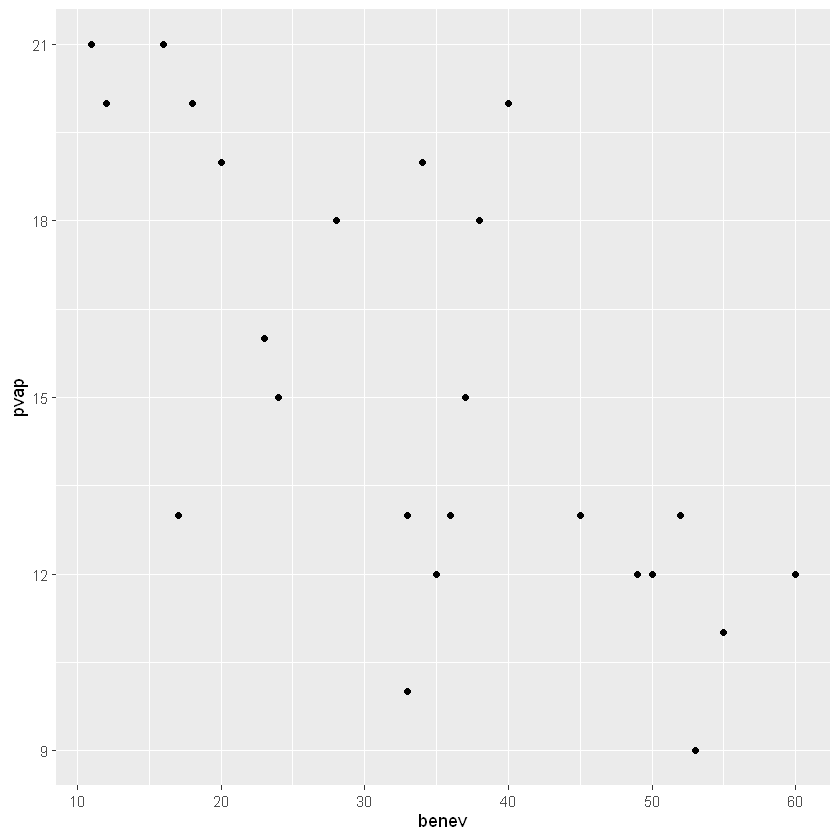

In [77]:
ggplot(europe, aes(x = benev, y = pvap)) +
  geom_point() +
  labs(x = "benev",
       y = "pvap")

**Interprétation**

- (chom, depsoc) -> nuage dispersé, pas de tendance
- (PIB, devel) -> tendance croissante nette, mais un point isolé avec un très fort PIB
- (benev, pvap) -> tendance négative modérée

## Matrice des corrélations des variables

### Matrice brute

In [78]:
cor_mat <- round(cor(europe, method = "pearson"), 2)
cor_mat
write.csv(cor_mat, file = "./graphs_&_tables/corr_matrix.csv", row.names = TRUE)

,benev,chom,depedu,depsoc,devel,pib,pvap,pvav,trvpv
benev,1.00,-0.41,0.28,0.58,0.62,0.56,-0.71,0.02,-0.63
chom,-0.41,1.00,-0.28,-0.19,-0.56,-0.55,0.32,-0.07,0.46
depedu,0.28,-0.28,1.00,0.34,0.23,-0.05,-0.36,0.50,-0.45
depsoc,0.58,-0.19,0.34,1.00,0.70,0.36,-0.50,0.14,-0.23
devel,0.62,-0.56,0.23,0.70,1.00,0.69,-0.30,0.23,-0.35
pib,0.56,-0.55,-0.05,0.36,0.69,1.00,-0.32,0.02,-0.18
pvap,-0.71,0.32,-0.36,-0.50,-0.30,-0.32,1.00,0.16,0.66
pvav,0.02,-0.07,0.50,0.14,0.23,0.02,0.16,1.00,-0.09
trvpv,-0.63,0.46,-0.45,-0.23,-0.35,-0.18,0.66,-0.09,1.00


### Visualisation de la matrice 

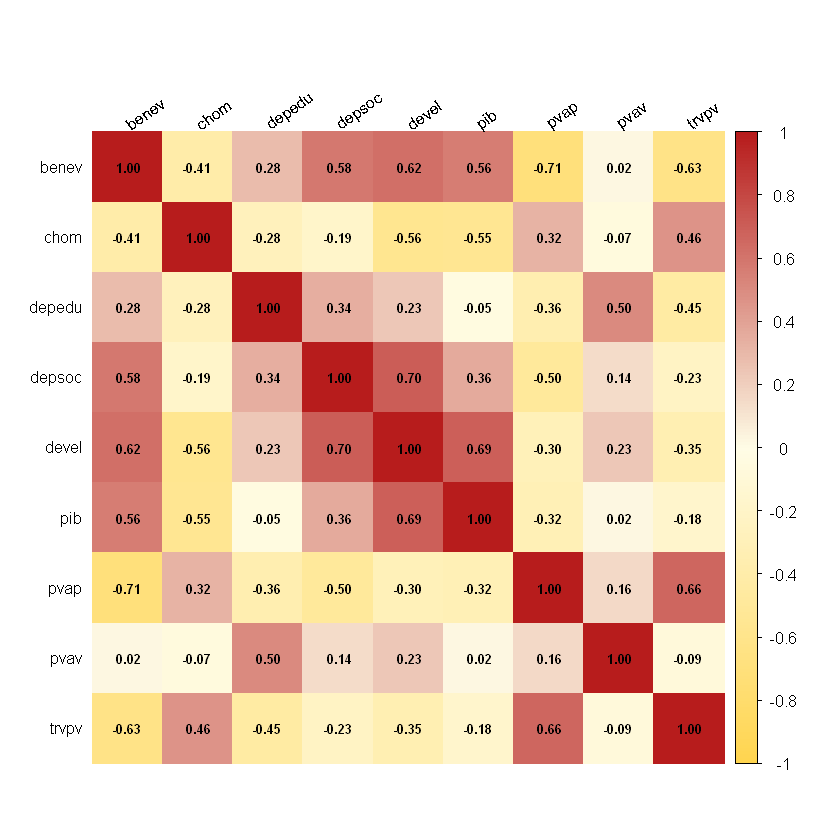

In [79]:
corrplot(cor_mat,
         method = "color",
         type = "full",
         diag = TRUE,
         col = colorRampPalette(c("#FFD54F", "#FFFDE7", "#B71C1C"))(200),
         tl.col = "black",
         tl.cex = 0.8,
         tl.srt = 35,
         addCoef.col = "black",
         number.cex = 0.65,
         mar = c(1, 1, 2, 1)
         )

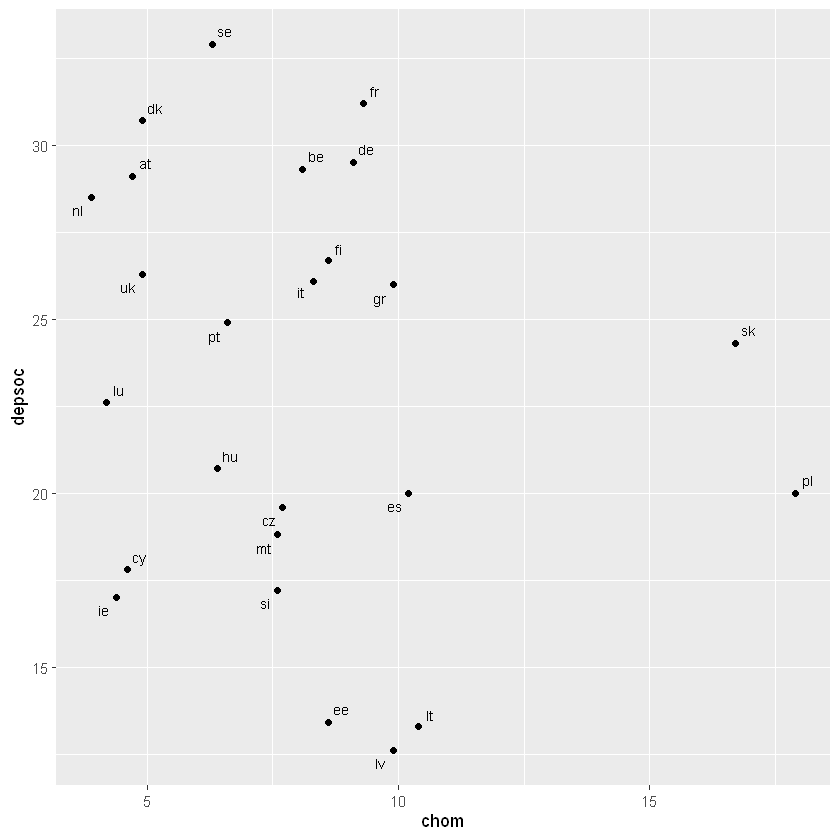

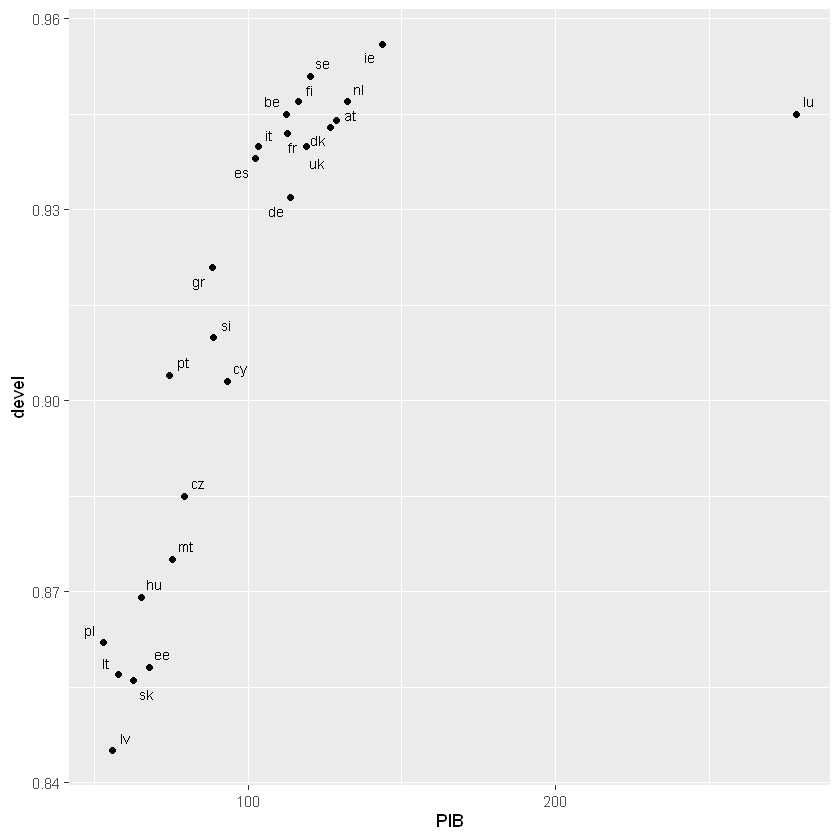

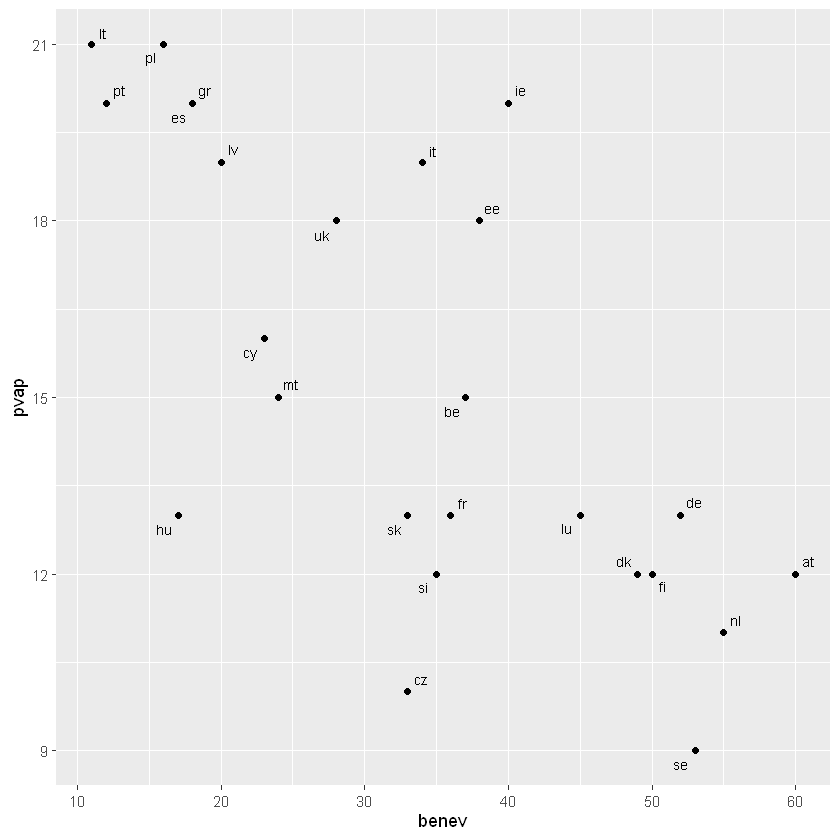

In [80]:
library(ggrepel)

# Graphe chom / depsoc
ggplot(europe, aes(x = chom, y = depsoc, label = rownames(europe))) +
  geom_point() +
  geom_text_repel(size = 3) +
  labs(x = "chom", y = "depsoc")

# Graphe pib / devel
ggplot(europe, aes(x = pib, y = devel, label = rownames(europe))) +
  geom_point() +
  geom_text_repel(size = 3) +
  labs(x = "PIB", y = "devel")

# Graphe benev / pvap
ggplot(europe, aes(x = benev, y = pvap, label = rownames(europe))) +
  geom_point() +
  geom_text_repel(size = 3) +
  labs(x = "benev", y = "pvap")

**Détection d'individus anormaux**

Couple `(chom, depsoc)` -> 
- ee, lv et lt se détachent nettement en bas du graphe
- sk et pl sont isolés à droite 

**donc** : ces outliers tirent dans des directions contradictiones et s'annulent mutuellement ce qui fait chuter la corrélation à -0.19

Couple `(PIB, devel)`->
- lu est complètement isolé à droite
- ie en haut à gauche a l'IDH le plus élevé avec un PIB dans la moyenne
- lv en bas à gauche: PIB et IDH tous les deux faibles

**donc** lu déforme l'axe horizontal et affaiblit le coefficient, car son PIB n'est pas proportionnellement reflété dans son IDH

Couple `(benev, pvap)`->
- lt et pl sont isolés en haut à gauche : fort taux de pauvreté des actifs mais bénévolat très faible
- ie se détache en haut à droite : pvap élevé avec un bénévolat 
  dans la moyenne, rompant la tendance décroissante
- se et cz sont isolés en bas : pvap parmi les plus faibles avec des niveaux de bénévolat très différents, 
  ce qui introduit une dispersion verticale importante

**donc** : la tendance négative générale est bien visible (pays nordiques en bas à droite, pays d'Europe de l'Est en haut à gauche), mais les outliers 
comme ie, cz et hu s'écartent de cette trajectoire et affaiblissent légèrement le coefficient

# Première ACP

### Pré-traitement du df avant manipulations

In [81]:
# conversion requise par FactoMineR
europe <- as.data.frame(europe)

## Centrer et réduire les données

In [82]:
# scale.unit = TRUE centre et réduit les données(ACP normée)
# ncp = 4 indique que l'on souhaite conserver les 4 premières composantes principales
res.pca <- PCA(europe_num, scale.unit = TRUE, ncp = 4, graph = FALSE)

## Variances des composantes principales

In [83]:
# $eig renvoie les valeurs propres, les pourcentages de variance expliquée et les pourcentages de variance cumulée
variances_cp <- data.frame(
  Axe = paste0("Dim.", 1:4),
  Variance = round(res.pca$eig[1:4, 1], 2)
)

variances_cp
write.csv(variances_cp, file = "./graphs_&_tables/variances_cp.csv", row.names = FALSE)

,Axe,Variance
,<chr>,<dbl>
comp 1,Dim.1,3.36
comp 2,Dim.2,1.46
comp 3,Dim.3,1.25
comp 4,Dim.4,0.91


## Tableau de corrélation des variables

In [84]:
corr_variables <- round(res.pca$var$cor[, 1:4], 2)
corr_variables
write.csv(corr_variables, file = "./graphs_&_tables/corr_variables.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
chom,-0.70,0.19,-0.04,0.58
depedu,0.53,0.74,-0.04,-0.02
depsoc,0.70,-0.02,0.14,0.66
devel,0.83,-0.23,0.39,0.10
pib,0.65,-0.56,0.29,-0.13
pvap,-0.69,0.01,0.61,-0.21
pvav,0.24,0.67,0.61,-0.11
trvpv,-0.68,-0.24,0.50,0.25


Coordonées des variables => corrélations variable / composante

Toutes les variables ont une forte corrélation avec Dim1 -> effet de taille

## Coordonées des individus sur les axes

In [85]:
coord_individus <- round(res.pca$ind$coord[, 1:4], 2)
coord_individus
write.csv(coord_individus, file = "./graphs_&_tables/coord_individus.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
at,1.74,-0.81,-0.28,0.31
be,1.65,0.74,0.22,0.39
cy,0.10,0.23,-0.91,-1.22
cz,-0.17,-0.74,-2.58,-0.31
de,0.92,-0.75,-0.65,0.93
dk,3.19,2.36,0.49,0.06
ee,-1.97,0.32,-0.93,-1.24
es,-1.41,-1.18,1.09,0.20
fi,1.91,0.97,-0.24,0.34
fr,1.42,0.21,-0.08,1.19


## Contribution des individus aux axes 

In [86]:
# contribution des individus aux axes en pourcentage
contrib_individus <- round(res.pca$ind$contrib[, 1:4], 2)
contrib_individus
write.csv(contrib_individus, file = "./graphs_&_tables/contrib_individus.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
at,3.58,1.81,0.25,0.43
be,3.25,1.48,0.16,0.67
cy,0.01,0.15,2.67,6.55
cz,0.03,1.50,21.36,0.42
de,1.00,1.54,1.37,3.77
dk,12.13,15.19,0.76,0.01
ee,4.60,0.27,2.78,6.70
es,2.37,3.83,3.82,0.17
fi,4.34,2.56,0.19,0.51
fr,2.40,0.12,0.02,6.21


## Faire une représentation graphique des valeurs propres

In [87]:
png("./graphs_&_tables/valeurs_propres.png", width = 800, height = 600, res = 120)

# récupérer les valeurs propres
vp <- res.pca$eig[, 1]

plot(1:length(vp), vp, type = "b", pch = 19,
     xlab = "Axes principaux",
     ylab = "Valeurs propres")


# ligne du critère de Kaiser
abline(h = 1, col = "red", lty = 2)

legend("topright",
       legend = expression("Critère de Kaiser (" * lambda == 1 * ")"),
       col = "red",
       lty = 2,
       lwd = 1,
       bty = "n")

dev.off()

pdf 
  2

Selon la règle de Kaiser (valeur propre > 1, ligne rouge) :

2 composantes principales sont à retenir: l'axe 1 (~8.5) et l'axe 2 (~1.2) sont au-dessus du seuil, l'axe 3 passe déjà en dessous.

## Table des valeurs propre, pourcentage de variage et cumul

In [88]:
res_filtre <- round(res.pca$eig, 2)
res_filtre

,eigenvalue,percentage of variance,cumulative percentage of variance
comp 1,3.36,42.01,42.01
comp 2,1.46,18.30,60.31
comp 3,1.25,15.63,75.94
comp 4,0.91,11.43,87.37
comp 5,0.41,5.09,92.46
comp 6,0.35,4.37,96.83
comp 7,0.19,2.38,99.21
comp 8,0.06,0.79,100.00


## Pourcentage d'inertie totale expliquée par le sous-espace principal correspondant

In [89]:
# Extraction des lignes où la valeur propre est > 1, puis arrondi à 2 décimales
res_filtre <- round(res.pca$eig[res.pca$eig[, 1] > 1, ], 2)

# Affichage du résultat
res_filtre

,eigenvalue,percentage of variance,cumulative percentage of variance
comp 1,3.36,42.01,42.01
comp 2,1.46,18.30,60.31
comp 3,1.25,15.63,75.94


2 axes sont retenus, le 1 et 2 et expliquent à eux seuls 73.91% de l'inertie

## Tracer le cercle de corrélation des variables

pdf 
  2

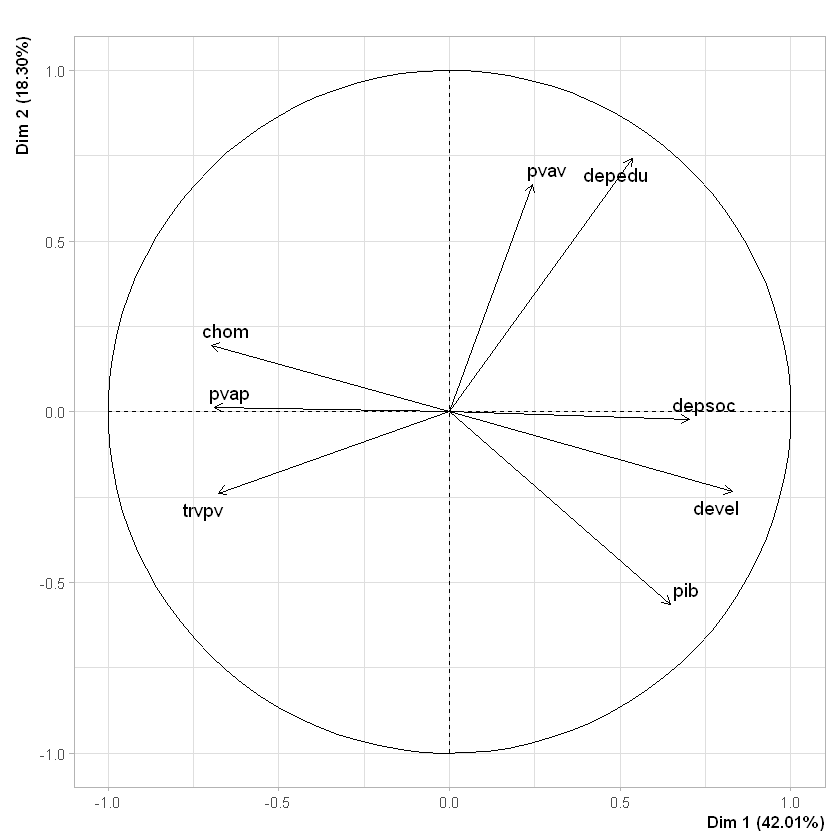

In [90]:
png("./graphs_&_tables/cercle_correlation.png", width = 800, height = 800, res = 120)

# choix = "var" indique que l'on souhaite afficher les variables
plot(res.pca, choix = "var", axes = c(1, 2), title = " ")

dev.off()

# Affichage
plot(res.pca, choix = "var", axes = c(1, 2), title="")

### Tableau des coordonnées des valeurs sur le cercle

In [91]:
corr_vars <- round(res.pca$var$coord[, 1:2], 2)

axe_dominant <- apply(corr_vars, 1, function(x) {
  if (abs(x[1]) > abs(x[2])) {
    paste0("Dim 1 (", ifelse(x[1] >= 0, "+", "-"), ")")
  } else if (abs(x[2]) > abs(x[1])) {
    paste0("Dim 2 (", ifelse(x[2] >= 0, "+", "-"), ")")
  } else {
    "Dim 1 et 2"
  }
})

tab_axes <- data.frame(
  Variable = rownames(corr_vars),
  `Axe dominant` = axe_dominant,
  `r (Dim 1)` = corr_vars[, 1],
  `r (Dim 2)` = corr_vars[, 2],
  row.names = NULL,
  check.names = FALSE
)

tab_axes
write.csv(tab_axes, file = "./graphs_&_tables/axes_variables.csv", row.names = FALSE)

Variable,Axe dominant,r (Dim 1),r (Dim 2)
<chr>,<chr>,<dbl>,<dbl>
chom,Dim 1 (-),-0.70,0.19
depedu,Dim 2 (+),0.53,0.74
depsoc,Dim 1 (+),0.70,-0.02
devel,Dim 1 (+),0.83,-0.23
pib,Dim 1 (+),0.65,-0.56
pvap,Dim 1 (-),-0.69,0.01
pvav,Dim 2 (+),0.24,0.67
trvpv,Dim 1 (-),-0.68,-0.24


Toutes les variables sont dominées par Dim1, aucune n'est exclusive à Dim2 ce qui confirme que l'axe 2 est secondaire et difficile à interpréter seul 

**effet de taille important**

# ACP sans `lu`

### Centrer et réduire les données sans lu

In [92]:
no_lu <- europe[rownames(europe) != "lu", ]

In [93]:
# scale.unit = TRUE centre et réduit les données(ACP normée)
# ncp = 4 indique que l'on souhaite conserver les 4 premières composantes principales
res.pca_lu <- PCA(no_lu, scale.unit = TRUE, ncp = 4, graph = FALSE)

## Variances des composantes principales pour les 4 premiers axes principaux

In [94]:
# $eig renvoie les valeurs propres, les pourcentages de variance expliquée et les pourcentages de variance cumulée
variances_cp_lu <- data.frame(
  Axe = paste0("Dim.", 1:4),
  Variance = round(res.pca_lu$eig[1:4, 1], 2)
)

variances_cp_lu
write.csv(variances_cp_lu, file = "./graphs_&_tables/variances_cp_lu.csv", row.names = FALSE)

,Axe,Variance
,<chr>,<dbl>
comp 1,Dim.1,4.56
comp 2,Dim.2,1.40
comp 3,Dim.3,1.13
comp 4,Dim.4,0.91


## Corrélations des variables

In [95]:
corr_variables_lu <- round(res.pca_lu$var$cor[, 1:4], 2)
corr_variables_lu
write.csv(corr_variables_lu, file = "./graphs_&_tables/corr_variables_lu.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
benev,0.85,-0.28,0.07,0.12
chom,-0.65,-0.08,0.08,0.65
depedu,0.57,0.27,-0.63,0.21
depsoc,0.72,0.07,0.36,0.51
devel,0.83,0.29,0.42,-0.07
pib,0.89,0.20,0.31,-0.17
pvap,-0.68,0.57,0.25,-0.26
pvav,0.26,0.82,-0.35,0.14
trvpv,-0.74,0.35,0.36,0.22


## Coordonées des individus

### Coordonées de `lu`

In [96]:
# Coordonnées de "lu" en individu supplémentaire
# predict() projette lu dans l'espace de l'ACP construite sans lui, ce qui en fait un individu supplémentaire.
lu_sup <- predict(res.pca_lu, newdata = europe["lu", ])

lu_coord <- as.data.frame(round(lu_sup$coord[, 1:4], 2))
lu_coord

,"round(lu_sup$coord[, 1:4], 2)"
,<dbl>
Dim.1,3.30
Dim.2,0.26
Dim.3,3.61
Dim.4,-2.11


### Coordonées des autres individus sur les axes

In [103]:
# Coordonnées des autres individus (no_lu) sur les 4 premiers axes
coord <- round(res.pca_lu$ind$coord[, 1:4], 2)
coord
write.csv(coord, file = "./graphs_&_tables/coord_no_lu.csv", row.names = TRUE)  

,Dim.1,Dim.2,Dim.3,Dim.4
at,2.57,-0.77,0.97,-0.11
be,1.78,0.49,-0.11,0.36
cy,-0.15,-0.40,-0.96,-1.23
cz,-0.24,-2.61,-0.35,-0.60
de,1.54,-1.16,1.09,0.46
dk,3.60,1.36,-1.76,0.81
ee,-1.73,-0.91,-0.93,-0.84
es,-1.56,0.68,1.72,-0.48
fi,2.41,0.00,-0.57,0.61
fr,1.54,-0.03,0.42,0.93


## Contributions aux axes (en %) 

In [104]:
# Contributions des individus actifs (en %)
contrib <- as.data.frame(round(res.pca_lu$ind$contrib[, 1:4], 2))
contrib
write.csv(contrib, file = "./graphs_&_tables/contrib_no_lu.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
,<dbl>,<dbl>,<dbl>,<dbl>
at,6.05,1.75,3.50,0.05
be,2.91,0.73,0.04,0.57
cy,0.02,0.47,3.41,6.93
cz,0.05,20.30,0.45,1.62
de,2.16,4.01,4.41,0.96
dk,11.86,5.53,11.40,2.99
ee,2.75,2.48,3.19,3.19
es,2.22,1.37,10.98,1.04
fi,5.32,0.00,1.18,1.71


## Qualités de représentation par chacun des axes (en % encore)

In [105]:
# Qualités de représentation (cos2) des individus actifs (en %)
cos2 <- as.data.frame(round(res.pca_lu$ind$cos2[, 1:4] * 100, 2))
cos2
write.csv(cos2, file = "./graphs_&_tables/cos2_no_lu.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
,<dbl>,<dbl>,<dbl>,<dbl>
at,72.45,6.45,10.35,0.12
be,67.84,5.21,0.26,2.69
cy,0.38,2.88,16.64,27.46
cz,0.71,84.67,1.52,4.40
de,39.71,22.73,20.10,3.54
dk,67.11,9.62,15.95,3.40
ee,44.11,12.25,12.63,10.28
es,35.64,6.79,43.62,3.35
fi,81.12,0.00,4.46,5.22


## Combien de composantes principales faut-il retenir ?

In [100]:
png("./graphs_&_tables/scree_plot_lu.png", width = 800, height = 600, res = 120)

# récupérer les valeurs propres
vp_lu <- res.pca_lu$eig[, 1]

plot(1:length(vp_lu), vp_lu, type = "b", pch = 19,
     xlab = "Axes principaux",
     ylab = "Valeurs propres")


# ligne du critère de Kaiser
abline(h = 1, col = "red", lty = 2)

legend("topright",
       legend = expression("Critère de Kaiser (" * lambda == 1 * ")"),
       col = "red",
       lty = 2,
       lwd = 1,
       bty = "n")

dev.off()

pdf 
  2

In [101]:
res_filtre <- round(res.pca_lu$eig, 2)
res_filtre

,eigenvalue,percentage of variance,cumulative percentage of variance
comp 1,4.56,50.61,50.61
comp 2,1.40,15.56,66.17
comp 3,1.13,12.51,78.69
comp 4,0.91,10.16,88.84
comp 5,0.49,5.43,94.28
comp 6,0.22,2.44,96.72
comp 7,0.19,2.13,98.85
comp 8,0.08,0.94,99.79
comp 9,0.02,0.21,100.00


##  La qualité globale de l'analyse a-t-elle été modifiée?

Avec lu : (3.36 + 1.46 + 1.25) / 8 ≈ 75.9% de variance expliquée sur 3 axes
Sans lu : (4.56 + 1.40 + 1.13) / 9 ≈ 78.8% de variance expliquée sur 3 axes

→ La qualité globale s'est légèrement améliorée après retrait de lu.
Le changement le plus notable est sur Dim.1 qui passe de 3.36 à 4.56 : lu perturbait fortement le premier axe (via son PIB très atypique), en le retirant on concentre encore plus d'information sur cet axe. Le nombre de composantes à retenir reste identique (3)